# Latent-Regime vs Labelling — Topology Comparison

## What this notebook is for

The Hormuz model reports the probability of three crisis **scenarios** (we abbreviate them
**Stress**, **Prolonged**, **Severe**). There are two fundamentally different ways to wire the
`Scenario` node into the network, and this notebook compares them head-to-head and explains,
in plain language, why one is better — and the one question that statistics *cannot* answer.

| | **Labelling** (current default) | **Latent regime** (Plan 1) |
|---|---|---|
| Arrows | outcomes **→** Scenario (`{D,T,P} → S`) | Scenario **→** outcomes (`S → {D,T,P}`) |
| Meaning of `Scenario` | a **label** computed from the outcomes | a hidden **regime** that *causes* the outcomes |
| What `P(Scenario\|evidence)` is | a re-bucketing of the outcome probabilities | a genuine posterior over a latent cause |
| Built in code with | `build_network()` | `build_network("latent_regime")` |

**The three variables that define a scenario** (the "outcomes"):
`D` = Energy-infrastructure **D**amage, `T` = conflict dura**T**ion, `P` = diplomatic **P**ath.
**The upstream "context"** includes things like US military response (`M`), strait closure
(`C`), sanctions, negotiations, militia activity.

We keep the labelling model as the baseline — **nothing is deleted** until the reframe is
endorsed. Both models are mathematically valid; the questions are *which is more useful* and
*whether the scenarios justify calling them real regimes*.

## How to read this notebook (mini-glossary)

A few terms recur. In plain language:

- **Posterior `P(Scenario | evidence)`** — the model's probability for each scenario *after*
  seeing some evidence. Three numbers that sum to 1.
- **Credible interval (CI)** — we don't know the hand-elicited CPT numbers exactly. We jiggle
  them (Dirichlet draws) and re-run inference many times; the **80% CI** is the range the
  posterior spans. **Wide CI = the model is unsure even about its own probability.** Shown as
  the black whiskers on bars.
- **Bayes factor Λ(A,B)** — "the evidence is **Λ times more expected** if the true regime is A
  than if it is B." Λ=10 is strong evidence for A; Λ=1 is neutral. Governance teams ask for
  exactly this ("how much does this headline favour Severe over Stress?").
- **log-loss / Brier / accuracy** — scores for how well a model's predicted probabilities match
  reality on simulated data. **log-loss and Brier: lower is better. accuracy: higher is better.**
- **Markov blanket** — the set of nodes that, once known, make a node independent of *everything
  else* in the network. Central to Finding 1.
- **Mutual information `I(S; outcomes)`** — how many *bits* the outcomes reveal about the regime.
  0 bits = outcomes tell you nothing; `H(S)` bits = outcomes pin the regime exactly.
- **Off-mode mass** — the probability a regime produces outcomes *other than* its signature
  (e.g. a "Severe" regime occasionally yielding non-severe damage). Needed for regimes to be
  genuine overlapping causes rather than rigid definitions.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pgmpy.inference import VariableElimination

from src.network import build_network, STATES, SCENARIO_SIGNATURES
from src.inference import scenario_bayes_factors, clamped_scenario_likelihoods
from src.sensitivity import default_concentrations, scenario_credible_intervals
from scripts.compare_topologies import (
    BATTERY, point, posterior_table, uq_table, head_to_head,
    domain_evidence, data_driven_verdict, degeneracy_demo, SHORT, SCEN,
)

S = "Scenario"
D, T, P = "Energy_Infrastructure_Damage", "Conflict_Duration", "Diplomatic_Resolution_Path"
M, C = "US_Military_Response", "Strait_Operationally_Closed"
COLORS = ["#2e7d32", "#f9a825", "#c62828"]  # Stress=green, Prolonged=amber, Severe=red

lab = build_network("labelling")
lat = build_network("latent_regime")
vl, vt = VariableElimination(lab), VariableElimination(lat)

def dist(ve, ev):
    """P(Scenario | evidence) as a 3-vector [Stress, Prolonged, Severe]."""
    return point(ve, ev)

print("labelling:", len(lab.edges()), "edges  |  latent:", len(lat.edges()), "edges")
print("scenario order in every array below:", [SHORT[s] for s in SCEN])

labelling: 21 edges  |  latent: 23 edges
scenario order in every array below: ['Stress', 'Prolonged', 'Severe']


---
# The three headline findings

These are the load-bearing conclusions. Each is stated as a claim, demonstrated with a small
experiment, and followed by a plain-language **takeaway**. Everything after this section is the
detailed supporting evidence (seven verification angles + the domain-judgement unit).

## Finding 1 — the labelling model is *blind to context once outcomes are known*

This is the most important and most easily misread finding, so we spell it out with two cases.

**The principle (d-separation of a chain).** In a chain `A → B → C`, observing the middle node
`B` makes the ends conditionally independent: `A ⊥ C | B`. In the **labelling** model the wiring is

```
   context (M, C, sanctions, …)  →  {D, T, P}  →  Scenario
            A                          B            C
```

Every path from context to `Scenario` passes *through* the outcomes `{D,T,P}`. So once the
outcomes are observed, context and `Scenario` are d-separated — context can carry **no extra
information** about the scenario. In the **latent** model the wiring is different: `{M,C} →
Scenario` is a *direct* edge (and `Scenario → {D,T,P}`), so observing the outcomes does **not**
sit on the context→scenario path, and context keeps informing the regime.

**The subtle claim is therefore NOT "upstream context never matters."** It does. The claim is
about what happens **once the outcomes `D, T, P` are already observed**:

- **Case B — outcomes *not* observed.** If you change an upstream node (say military response),
  the outcomes' probabilities shift, and the scenario shifts too. *Both models do this,
  identically.* (Your intuition is right here.)
- **Case A — outcomes *already* observed.** Now you *additionally* learn the upstream context.
  Does your regime belief change? **Labelling: no — it is structurally frozen.** Its `Scenario`
  is *defined by* the outcomes, so once they're known, nothing else can inform it (its Markov
  blanket is exactly `{D, T, P}`). **Latent: yes** — it reasons "these severe outcomes happened
  in a *benign* military context, which is surprising for a true Severe regime, so I'll shift
  some belief toward Prolonged."

The cell below shows both cases with real numbers.

In [2]:
print("CASE B  —  change one upstream node (M), outcomes NOT observed")
print("  prior                :", np.round(dist(vl, {}), 3))
print("  labelling P(S|M=none):", np.round(dist(vl, {M: 'none'}), 3))
print("  latent    P(S|M=none):", np.round(dist(vt, {M: 'none'}), 3))
print("  => BOTH models move, and by the SAME amount. (Upstream matters when outcomes unknown.)")
print()
print("CASE A  —  outcomes D,T,P already observed, THEN add the same upstream node M")
base = {D: 'severe', T: 'long', P: 'closed'}      # a 'Severe-looking' set of outcomes
both = {**base, M: 'none'}                          # ...but in a benign (no military) context
print("  labelling  P(S | D,T,P)        :", np.round(dist(vl, base), 3))
print("  labelling  P(S | D,T,P, M=none):", np.round(dist(vl, both), 3), " <- IDENTICAL: frozen / blind")
print("  latent     P(S | D,T,P)        :", np.round(dist(vt, base), 3))
print("  latent     P(S | D,T,P, M=none):", np.round(dist(vt, both), 3), " <- MOVES toward Prolonged")

CASE B  —  change one upstream node (M), outcomes NOT observed
  prior                : [0.52  0.337 0.144]
  labelling P(S|M=none): [0.676 0.266 0.058]
  latent    P(S|M=none): [0.676 0.266 0.058]
  => BOTH models move, and by the SAME amount. (Upstream matters when outcomes unknown.)

CASE A  —  outcomes D,T,P already observed, THEN add the same upstream node M
  labelling  P(S | D,T,P)        : [0.01 0.09 0.9 ]
  labelling  P(S | D,T,P, M=none): [0.01 0.09 0.9 ]  <- IDENTICAL: frozen / blind
  latent     P(S | D,T,P)        : [0.023 0.269 0.708]
  latent     P(S | D,T,P, M=none): [0.026 0.394 0.58 ]  <- MOVES toward Prolonged


**How to read the next experiment.** We simulate 3000 worlds, then ask each model to guess
the scenario from the evidence, scored by log-loss / Brier / accuracy. We do it twice: giving
the model **only the outcomes** `{D,T,P}`, then **all observable nodes** (outcomes *and*
context). If a model can use context on top of outcomes, "all observables" should score better
than "emissions only".

In [3]:
h2h = head_to_head(lab, lat, n=3000)
hdr = f"{'evidence given':<18}{'model':<11}{'log-loss':>10}{'Brier':>9}{'accuracy':>10}"
print(hdr); print("-" * len(hdr))
for ev in ("emissions", "all_observables"):
    for mdl in ("labelling", "latent"):
        ll, br, ac = h2h[ev][mdl]
        print(f"{ev:<18}{mdl:<11}{ll:>10.4f}{br:>9.4f}{ac:>10.4f}")
print()
print("Read the 'labelling' rows: 'emissions' and 'all_observables' are IDENTICAL")
print("  -> giving it context on top of outcomes adds literally nothing (blind).")
print("Read the 'latent' rows: every score IMPROVES with all observables")
print("  -> it genuinely uses context to sharpen the regime estimate.")

evidence given    model        log-loss    Brier  accuracy
----------------------------------------------------------
emissions         labelling      0.8269   0.4932    0.6247
emissions         latent         0.7824   0.4701    0.6453
all_observables   labelling      0.8269   0.4932    0.6247
all_observables   latent         0.7636   0.4579    0.6590

Read the 'labelling' rows: 'emissions' and 'all_observables' are IDENTICAL
  -> giving it context on top of outcomes adds literally nothing (blind).
Read the 'latent' rows: every score IMPROVES with all observables
  -> it genuinely uses context to sharpen the regime estimate.


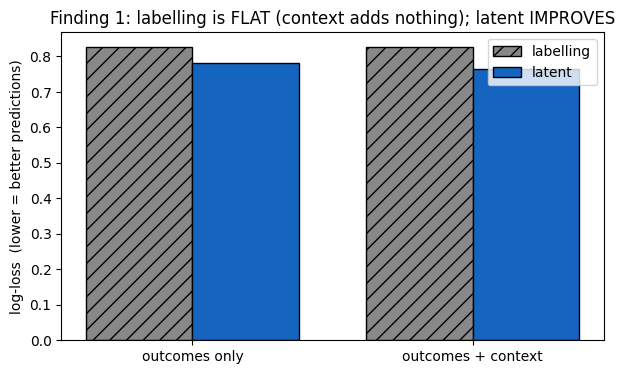

In [4]:
# Same point as a picture: log-loss (lower = better), emissions vs all-observables.
fig, ax = plt.subplots(figsize=(7, 4))
groups = ["emissions", "all_observables"]; x = np.arange(2); w = 0.38
ax.bar(x - w/2, [h2h[g]["labelling"][0] for g in groups], w, label="labelling",
       color="#888", hatch="//", edgecolor="k")
ax.bar(x + w/2, [h2h[g]["latent"][0] for g in groups], w, label="latent",
       color="#1565c0", edgecolor="k")
ax.set_xticks(x); ax.set_xticklabels(["outcomes only", "outcomes + context"])
ax.set_ylabel("log-loss  (lower = better predictions)")
ax.set_title("Finding 1: labelling is FLAT (context adds nothing); latent IMPROVES")
ax.legend(); plt.show()

> **Takeaway (Finding 1).** When an analyst observes both *what happened* (outcomes) and
> *the situation it happened in* (context), the labelling model throws the context away — it is
> structurally incapable of using it. The latent model uses it, which is why it predicts the
> true regime better. This is the single clearest argument for the reframe.

## Finding 2 — the labelling model is *overconfident*; the latent model is *honestly uncertain*

**How the point estimate is computed in each model.**

Labelling (a weighted average of hand-authored CPT columns):
$$P(S\mid E)=\sum_{d,t,p} \underbrace{P(S\mid d,t,p)}_{\text{elicited column}}\;P(d,t,p\mid E)$$
The benign-corner column is **`P(S | none,short,open) = [0.94, 0.05, 0.01]`** — near one-hot by
hand. So when evidence concentrates the outcomes on that corner, the posterior inherits ≈0.94.

Latent (a regime prior reweighted by emission likelihoods):
$$P(S\mid E)\;\propto\;\sum_{m,c} P(m,c\mid E)\,\underbrace{P(S\mid m,c)}_{\text{regime prior}}\,\prod_{x\in\{d,t,p\}} P(x\mid S,m,c)$$
The regime prior is non-extreme **even at the calmest context**: `P(S | M=none,C=no) = [0.69,
0.26, 0.05]`. And every emission keeps nonzero **off-mode mass** (`P(d≠signature | S) > 0`), so a
Severe/Prolonged regime can still produce benign-looking outcomes. Result: the posterior is
**capped** — `P(S | none,short,open) = [0.82, 0.15, 0.03]` (vs labelling's `[0.94, …]`), and full
de-escalation gives ≈0.68 not ≈0.90.

**How the credible interval is computed** — quantiles of $P(S\mid E;\theta^{(m)})$ over
resamples $\theta^{(m)}\sim\mathrm{Dir}(\kappa\,\bar\theta)$. The width depends on **how many
uncertain (κ=10) CPTs feed the answer**:
- labelling: ≈ **one** sharp column, near the simplex boundary → little room to move → narrow.
- latent: **four** CPTs (regime + 3 emissions) combined over context → variances **compound** → wider.

The cell below shows the numbers; the plot after it shows all of this at once.

In [5]:
uq = uq_table(lab, lat, m=200)              # m = number of Dirichlet resamples per config
uqmap = {r['config']: r for r in uq}
de = uqmap['deescalation_full']             # a full de-escalation news week
print("Evidence: full de-escalation  (talks succeed, no military response, calm strait)")
print("  labelling P(Scenario):", {SHORT[s]: round(de['lab_ci'][s][0], 3) for s in SCEN},
      " <- ~90% sure it's Stress")
print("  latent    P(Scenario):", {SHORT[s]: round(de['lat_ci'][s][0], 3) for s in SCEN},
      " <- a calibrated ~68%")
lab_w = np.mean([r['lab_width'] for r in uq]); lat_w = np.mean([r['lat_width'] for r in uq])
print(f"\nAverage 80% credible-interval WIDTH across all configs:")
print(f"  labelling {lab_w:.1f} percentage points   |   latent {lat_w:.1f} percentage points")
print("  -> the latent model's wider bands admit how uncertain a hidden regime really is.")

Evidence: full de-escalation  (talks succeed, no military response, calm strait)
  labelling P(Scenario): {'Stress': 0.903, 'Prolonged': 0.08, 'Severe': 0.016}  <- ~90% sure it's Stress
  latent    P(Scenario): {'Stress': 0.683, 'Prolonged': 0.257, 'Severe': 0.06}  <- a calibrated ~68%

Average 80% credible-interval WIDTH across all configs:
  labelling 12.3 percentage points   |   latent 21.5 percentage points
  -> the latent model's wider bands admit how uncertain a hidden regime really is.


**How to read the plot below.** Five evidence situations, side by side. In each panel the
three coloured bars are the scenarios (green=Stress, amber=Prolonged, red=Severe). For each
scenario there are **two bars**: the **hatched / pale** bar is the *labelling* model, the
**solid** bar is the *latent* model. The **black whisker** is the 80% credible interval (taller
whisker = more uncertainty). Watch three things:
- `no_evidence` and `D=severe`: the two models are **identical** (this is a correctness property,
  explained later).
- `deescalation_full`: labelling shoots to ~0.9 on Stress with a short whisker; latent is lower
  with a taller whisker (less overconfident).
- `mixed_closedC_successU1` (contradictory evidence): the two models disagree the most.

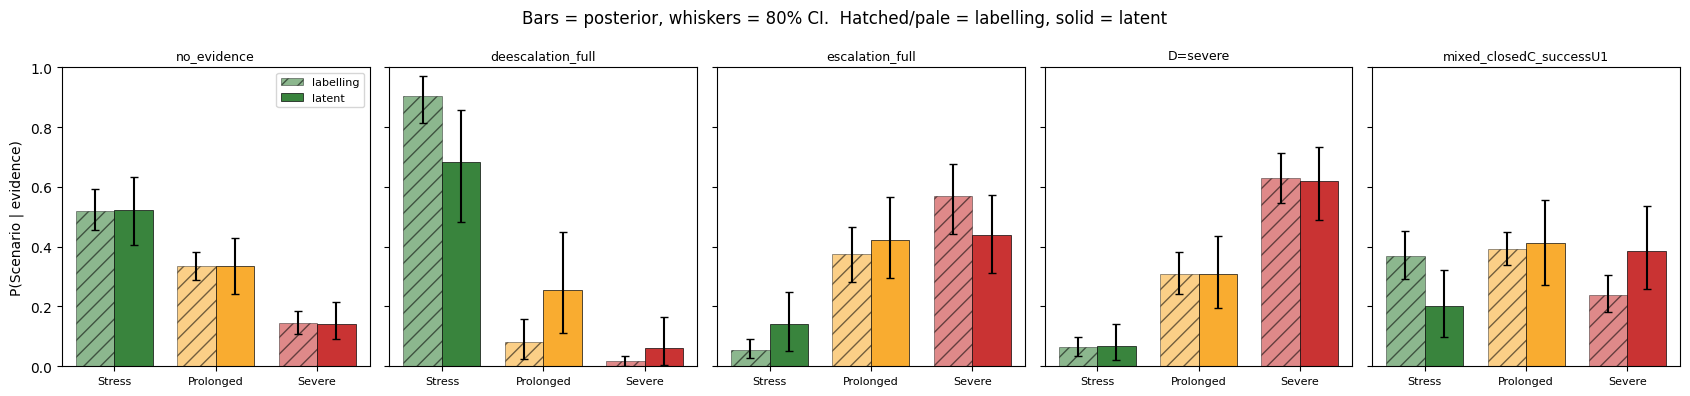

In [6]:
key = ["no_evidence", "deescalation_full", "escalation_full", "D=severe", "mixed_closedC_successU1"]
fig, axes = plt.subplots(1, len(key), figsize=(3.4*len(key), 4), sharey=True)
for ax, cfg in zip(axes, key):
    r = uqmap[cfg]; x = np.arange(3); w = 0.38
    for off, mdl, ci, alpha, hatch in [(-w/2, "labelling", r['lab_ci'], 0.55, "//"),
                                       ( w/2, "latent",   r['lat_ci'], 0.95, "")]:
        means = [ci[s][0] for s in SCEN]
        err = [[ci[s][0]-ci[s][1] for s in SCEN], [ci[s][2]-ci[s][0] for s in SCEN]]
        ax.bar(x+off, means, w, yerr=err, capsize=3, color=COLORS, alpha=alpha,
               hatch=hatch, edgecolor="k", linewidth=0.5, label=mdl)
    ax.set_title(cfg, fontsize=9); ax.set_xticks(x)
    ax.set_xticklabels([SHORT[s] for s in SCEN], fontsize=8); ax.set_ylim(0, 1)
axes[0].set_ylabel("P(Scenario | evidence)"); axes[0].legend(fontsize=8)
fig.suptitle("Bars = posterior, whiskers = 80% CI.  Hatched/pale = labelling, solid = latent")
plt.tight_layout(); plt.show()

> **Takeaway (Finding 2).** The labelling model's narrow intervals are *false precision*: it
> looks confident because its `Scenario` is mechanically tied to the outcomes, not because the
> evidence justifies it. The latent model's wider, more moderate posteriors are the honest
> picture when the thing you're inferring is a hidden cause.

## Finding 3 — finding "M7" is *not* fixed by the reframe (a correction to the plan)

**The problem, from scratch.** The CPT numbers are hand-elicited, so they are uncertain. That
forces a choice of how to report a single scenario probability:

1. **Point estimate** — run inference once on the CPTs *as written* (their elicited mean values
   $\bar\theta$). Call the result $f(\bar\theta)$, where $f$ = "the posterior $P(S\mid E)$".
2. **Resample mean** — acknowledge the uncertainty: draw many jiggled CPT sets
   $\theta^{(m)}\sim\mathrm{Dir}(\kappa\bar\theta)$, run inference on each, and **average** the
   posteriors: $\frac1M\sum_m f(\theta^{(m)})\approx \mathbb{E}_\theta[f(\theta)]$. (This is also
   the centre of the credible band.)

These two numbers disagree. **Why (the math):** $f$ is a *non-linear* function of $\theta$, and
for any non-linear $f$, Jensen's inequality says the average of the outputs ≠ the output at the
average:
$$\underbrace{\mathbb{E}_\theta[f(\theta)]}_{\text{resample mean}}\;\neq\;\underbrace{f(\mathbb{E}_\theta[\theta])}_{\approx\text{ point estimate}},\qquad \text{gap}\;\approx\;\tfrac12\,f''(\bar\theta)\,\mathrm{Var}(\theta).$$
This "Jensen gap" is **finding M7**. It exists for *any* non-trivial Bayesian network.

**The claim being tested.** Plan 1 predicted the reframe would *shrink* this gap (it blamed the
sharp labelling CPT). **It does not** — the gap is a generic property of non-linear inference,
roughly equal in both models.

**Is it concerning? No.** It is below ~1.3pp everywhere (near display precision), it is not a
bug, and the dashboard already reports the resample-mean (the honest, uncertainty-aware
summary). We keep it only as an honest correction to the plan.

**How to read the boxplot.** Each box = the gap (pp) across all ~24 configs; orange line =
median, box = middle 50%, whiskers = range. If the reframe closed M7 the *latent* box would sit
clearly lower. It doesn't.

point-vs-resample gap (percentage points):
  labelling : 95th percentile = 0.81 pp,  max = 0.81 pp
  latent    : 95th percentile = 0.96 pp,  max = 1.15 pp
  -> small in BOTH (well under ~1.3pp), and the latent gap is NOT smaller.


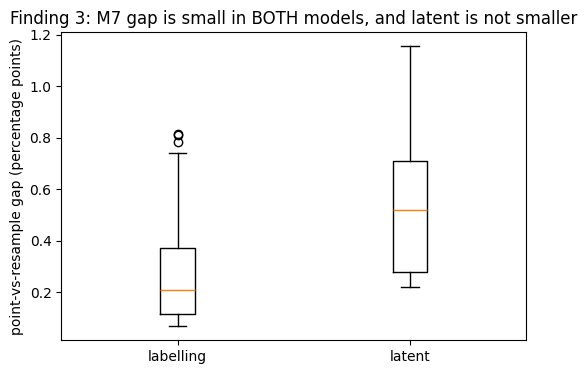

In [7]:
lab_g = [r['lab_gap'] for r in uq]; lat_g = [r['lat_gap'] for r in uq]
print(f"point-vs-resample gap (percentage points):")
print(f"  labelling : 95th percentile = {np.percentile(lab_g,95):.2f} pp,  max = {max(lab_g):.2f} pp")
print(f"  latent    : 95th percentile = {np.percentile(lat_g,95):.2f} pp,  max = {max(lat_g):.2f} pp")
print("  -> small in BOTH (well under ~1.3pp), and the latent gap is NOT smaller.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([lab_g, lat_g], tick_labels=["labelling", "latent"])
ax.set_ylabel("point-vs-resample gap (percentage points)")
ax.set_title("Finding 3: M7 gap is small in BOTH models, and latent is not smaller")
plt.show()

> **Takeaway (Finding 3).** M7 is a small, model-agnostic numerical artefact of non-linear
> inference, not something the reframe fixes. The dashboard already handles it correctly by
> plotting the resample-mean (the centre of the credible band). This does **not** weaken the
> case for the latent model — M7 was only ever a hoped-for side-benefit. Reporting it honestly
> is part of testing the *results*, not just the code.

---
# Supporting evidence — seven verification angles

The findings above rest on an implementation we checked from seven independent directions. Each
angle is a separate line of evidence; all are locked in as automated tests
(`tests/test_latent_regime.py`, 21 tests). Below we surface the key numbers with interpretation.

## Angles 1 & 4 — the new model is built *correctly*, and agrees with the old where it must

The latent CPTs were not invented from scratch — they are *derived* from the current model so
that they reproduce its joint distribution exactly. A consequence: the two models must agree to
**machine precision (~1e-16)** wherever the topology doesn't change the answer — the prior,
damage-only evidence `P(S|D)`, military-only evidence `P(S|M)`, and the joint `P(S,D,M,C)`.

**How to read the output.** The "max difference" numbers should be ~0 (≈1e-16). The divergence
table then shows *where* the models genuinely differ — and it's exactly the cases involving
**upstream / indirect** evidence, never pure damage evidence. That pattern is the fingerprint of
a correct derivation: same answer where the math forces it, different answer only where the
topology is supposed to matter.

In [8]:
print("Where the two models MUST agree (max |labelling - latent|, should be ~1e-16):")
print("  prior P(S)      :", f"{np.abs(dist(vl,{})-dist(vt,{})).max():.1e}")
print("  P(S|D=severe)   :", f"{np.abs(dist(vl,{D:'severe'})-dist(vt,{D:'severe'})).max():.1e}")
print("  P(S|M=major)    :", f"{np.abs(dist(vl,{M:'major'})-dist(vt,{M:'major'})).max():.1e}")
post = posterior_table(lab, lat)
print("\nWhere they genuinely DIVERGE (largest gaps; L1 = total absolute difference):")
print(f"  {'evidence':<26}{'labelling':<22}{'latent':<22}{'L1':>5}")
for r in sorted(post, key=lambda r: -r['l1'])[:5]:
    print(f"  {r['config']:<26}{str(np.round(r['labelling'],3)):<22}{str(np.round(r['latent'],3)):<22}{r['l1']:>5.2f}")
print("  (note: every large-divergence row involves upstream/indirect evidence, not bare D)")

Where the two models MUST agree (max |labelling - latent|, should be ~1e-16):
  prior P(S)      : 5.6e-17
  P(S|D=severe)   : 1.1e-16
  P(S|M=major)    : 0.0e+00

Where they genuinely DIVERGE (largest gaps; L1 = total absolute difference):
  evidence                  labelling             latent                   L1
  deescalation_full         [0.903 0.081 0.016]   [0.683 0.262 0.055]    0.44
  U1=success                [0.761 0.182 0.058]   [0.568 0.318 0.114]    0.39
  deescalation_partial      [0.844 0.129 0.027]   [0.658 0.278 0.064]    0.37
  mixed_closedC_successU1   [0.373 0.392 0.235]   [0.195 0.412 0.393]    0.35
  contradict_severeD_openP  [0.151 0.452 0.397]   [0.11  0.322 0.568]    0.34
  (note: every large-divergence row involves upstream/indirect evidence, not bare D)


## Angle 2 — the new graph is valid, and its emissions match the scenario narratives

Three structural checks: the latent network is a valid Bayesian network; every probability
column sums to 1; and **no cell is exactly zero** (so Bayes factors can never blow up to
infinity — see Angle 5). Then the **narrative-mode check**: for each regime, the *most likely*
outcome it generates should match the client's written signature (e.g. a Severe regime should
most likely produce *severe* damage).

**How to read the table.** One row per (regime, outcome-variable). The columns are:

| column | meaning |
|---|---|
| **regime** | the scenario (Stress, Severe) |
| **outcome** | which outcome variable — *Energy* = **D**amage, *Conflict* = dura**T**ion, *Diplomatic* = **P**ath (labels are truncated) |
| **model mode** | the model's *most-probable* value for that outcome: $rg\max_x P(	ext{outcome}=x \mid 	ext{regime, characteristic context})$ |
| **narrative** | what the client's written scenario says that outcome should be |
| **match** | `OK` if model mode = narrative |

So the row *Severe / Energy / severe / severe / OK* reads: "a Severe regime most-likely produces
*severe* damage — matching the narrative." All `OK` means the auto-derived emission CPTs put
their peaks exactly where the human narratives say they should. (The fuzzy middle regime,
Prolonged, is omitted here — its duration mode lands on 'medium' not 'long', flagged openly for
re-elicitation in Plan 4.)

In [9]:
print("min probability cell over the whole latent network:",
      f"{min(float(np.asarray(c.get_values()).min()) for c in lat.get_cpds()):.2e}  (>0 => Bayes factors stay finite)")
print()
ctx = {"Stress_Mitigates": {M:"none", C:"no", "US_Iran_Negotiations":"success",
                            "Third_Party_Mediation":"active", "Iranian_Regime_Stability":"stable"},
       "Severe_Closure":   {M:"major", C:"full", "US_Iran_Negotiations":"breakdown",
                            "Third_Party_Mediation":"none", "Iranian_Regime_Stability":"unstable"}}
par = {D:[M,C], T:["US_Iran_Negotiations","Third_Party_Mediation",M],
       P:["US_Iran_Negotiations","Third_Party_Mediation","Iranian_Regime_Stability"]}
print(f"{'regime':<18}{'outcome':<10}{'model mode':<11}{'narrative':<11}match")
for sc in ctx:
    want = dict(zip([D, T, P], SCENARIO_SIGNATURES[sc]))
    for ch in (D, T, P):
        cpd = lat.get_cpds(ch); context = {S: sc, **{p: ctx[sc][p] for p in par[ch]}}
        vec = [cpd.get_value(**{ch: cs}, **context) for cs in STATES[ch]]
        got = STATES[ch][int(np.argmax(vec))]
        print(f"{sc:<18}{ch.split('_')[0]:<10}{got:<11}{want[ch]:<11}{'OK' if got==want[ch] else 'MISS'}")

min probability cell over the whole latent network: 9.62e-04  (>0 => Bayes factors stay finite)

regime            outcome   model mode narrative  match
Stress_Mitigates  Energy    none       none       OK
Stress_Mitigates  Conflict  short      short      OK
Stress_Mitigates  Diplomaticopen       open       OK
Severe_Closure    Energy    severe     severe     OK
Severe_Closure    Conflict  long       long       OK
Severe_Closure    Diplomaticclosed     closed     OK


## Angle 3 — the model reasons correctly (information flow + Bayes factors)

Two checks. First, **does evidence reach the regime through the graph?** Every upstream node
*should* be able to move `P(S)` — except `Third_Party_Mediation`, which is a deliberate,
documented **blind spot** (mediation news only reaches the regime indirectly in v1).

**How to read it:** the number is how much `P(S)` moves (total absolute change) for the
best-case state of that node. Non-zero = the evidence gets through. `Third_Party_Mediation`
should be ~0 — and it is, by design.

Second, the **Bayes factor** Λ(Severe, Stress) for "damage was severe" is computed two
independent ways (a ratio identity, and a direct three-clamped computation). They must agree —
a cross-check that the inference is right.

In [10]:
prior = dist(vt, {})
print("Can evidence on each node reach the regime? (total |change| in P(S)):")
for node in ["Sanctions_Trajectory", "US_Military_Response", "Strait_Operationally_Closed",
             D, "Third_Party_Mediation"]:
    sh = max(float(np.abs(dist(vt, {node: s}) - prior).sum()) for s in STATES[node])
    tag = "   <-- BLIND SPOT (intentional, documented)" if node == "Third_Party_Mediation" else ""
    print(f"  {node:<30}{sh:6.3f}{tag}")
bf = scenario_bayes_factors(lat, {D: "severe"})
pe = clamped_scenario_likelihoods(lat, {D: "severe"})
lr = bf['lambda']['Severe_Closure']['Stress_Mitigates']
print(f"\nBayes factor  Λ(Severe, Stress | damage=severe):")
print(f"  = {lr:.1f}  -> severe damage is {lr:.0f}x more expected under a Severe regime than a Stress regime")
print(f"  cross-check (independent method): {pe['Severe_Closure']/pe['Stress_Mitigates']:.1f}  (matches)")

Can evidence on each node reach the regime? (total |change| in P(S)):
  Sanctions_Trajectory           0.167
  US_Military_Response           0.735
  Strait_Operationally_Closed    0.676
  Energy_Infrastructure_Damage   0.969
  Third_Party_Mediation          0.000   <-- BLIND SPOT (intentional, documented)

Bayes factor  Λ(Severe, Stress | damage=severe):
  = 36.3  -> severe damage is 36x more expected under a Severe regime than a Stress regime
  cross-check (independent method): 36.3  (matches)


## Angle 5 — the two capabilities the reframe *adds*

These are things the labelling model **cannot do at all**:

1. **Bayes factors stay finite and interpretable.** In the labelling model, if you push the
   "scenario = definition" reading to its limit, the likelihood of severe damage under a Stress
   regime is *exactly zero*, so the Bayes factor is **infinite** — a meaningless "the definition
   forbids it" answer. The latent model gives a finite, sensible number (severe damage is rare
   but not impossible under a calming regime).
2. **You can set the regime prior independently** (`P(S | M, C)` is a real knob); the labelling
   model has no such parameter.
3. **Evidence composes** — independent observations multiply, as Bayes' rule should.

In [11]:
deg = degeneracy_demo(lat)
print("Evidence = {damage = severe}.  Likelihood of this under each regime, and the Bayes factor:")
print(f"  HARD labelling : P(severe | Stress) = {deg['hard_PStress']:.3f}  ->  Λ(Severe,Stress) = "
      f"{'INFINITE (degenerate, meaningless)' if not np.isfinite(deg['hard_lambda']) else round(deg['hard_lambda'],1)}")
print(f"  latent regime  : P(severe | Stress) = {deg['latent_PStress']:.3f}  ->  Λ(Severe,Stress) = "
      f"{deg['latent_lambda']:.1f}  (finite, interpretable)")

Evidence = {damage = severe}.  Likelihood of this under each regime, and the Bayes factor:
  HARD labelling : P(severe | Stress) = 0.000  ->  Λ(Severe,Stress) = INFINITE (degenerate, meaningless)
  latent regime  : P(severe | Stress) = 0.012  ->  Λ(Severe,Stress) = 36.3  (finite, interpretable)


## Angles 6 & 7 — calibration on simulated truth, and robustness

**The experiment, step by step.**
1. **Simulate** 3000 "worlds" from the latent model. Each world has a **true** regime $s^\star$
   (drawn by the model) plus concrete values for every other node.
2. For each world, show the model only the **observables** (every node except `Scenario`) and
   compute the posterior $P(S \mid \text{observables})$.
3. The model's **"guess"** is the single most-probable scenario:
   $\widehat{s} = \arg\max_{s} P(S=s \mid \text{observables})$ — i.e. it turns the soft posterior
   into one hard pick.
4. **Confusion matrix:** $\text{conf}[i][j] = \Pr(\widehat{s}=j \mid s^\star=i)$, estimated by
   counting. Each **row is a true regime**, each **column is the guess**, rows sum to 1.

**How to read it.** The diagonal (true = guess) is "got it right"; off-diagonal cells are
specific confusions. A bright diagonal ⇒ regimes are easy to tell apart. Watch the middle row
(**Prolonged**): its mass is smeared onto Stress and Severe — the model frequently *mistakes*
Prolonged for a neighbour. That is the "weak middle regime" quantified — honest input for the
domain judgement below, not a bug.

*(Caveat: worlds are generated by the latent model, so this assumes the latent regimes are the
true data-generating process. Angle 7 — κ-robustness — is checked in the test suite: point
estimates don't depend on κ, and the M7 finding holds for κ ∈ {10, 20, 50}.)*

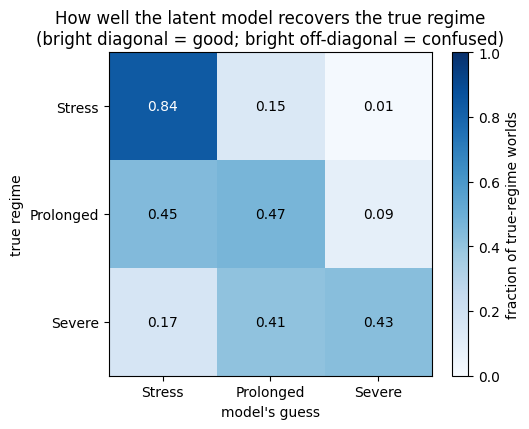

In [12]:
conf = np.array(h2h["confusion"])
fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(conf, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels([SHORT[s] for s in SCEN]); ax.set_yticklabels([SHORT[s] for s in SCEN])
ax.set_xlabel("model's guess"); ax.set_ylabel("true regime")
ax.set_title("How well the latent model recovers the true regime\n(bright diagonal = good; bright off-diagonal = confused)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{conf[i,j]:.2f}", ha="center", va="center",
                color="white" if conf[i, j] > 0.5 else "black")
fig.colorbar(im, fraction=0.046, label="fraction of true-regime worlds"); plt.show()

---
# Domain-signature check — does the model look like *real regimes*? (self-contained)

The deep question is whether the scenarios are **real latent regimes** or just **relabelled
buckets of outcomes**. We make this *decidable from the data* by asking: does the constructed
latent model carry the measurable **signature** of genuine regimes? A genuine latent regime is
(a) **identifiable** from data, (b) **overlapping** rather than a rigid partition, and (c) such
that **context adds information** beyond the outcomes. Each is a number with a threshold:

| criterion | what it measures | how it's computed | passes if |
|---|---|---|---|
| **C1 distinguishable** | regimes are recoverable from outcomes | Bayes-optimal accuracy $\sum_o \max_s P(s,o)$ vs. the no-information baseline (just guess the most-common regime) | accuracy > baseline + 0.05 |
| **C2 generative, not a bucket** | regimes *overlap* (a rigid partition would be perfectly separable) | accuracy < 1 **and** max pairwise outcome-overlap $1-\mathrm{TV}$ between regimes | accuracy < 1 and overlap > 0.20 |
| **C3 context-informative** | context tells you about the regime *beyond* the outcomes (Finding 1, as a number) | mean over simulated worlds of $\mathrm{TV}\big(P(S\mid\text{outcomes}),\,P(S\mid\text{outcomes},\text{context})\big)$ | avg shift > 2pp |

If all three pass, the model has the structure of real overlapping regimes (and the labelling
model's overconfidence is then a genuine defect). If C1 fails it's mush; if C2 fails it's a
relabelled partition (the labelling model is the honest choice); if C3 fails the extra
machinery buys nothing.

In [13]:
v = data_driven_verdict(lat)
c = v["criteria"]
print("DOMAIN-SIGNATURE CHECK (computed from the model — no external input)\n")
c1 = c["C1_distinguishable"]
print(f"  C1 distinguishable     : accuracy {c1['value']:.3f} vs baseline {c1['baseline']:.3f}"
      f"   -> {'PASS' if c1['pass'] else 'FAIL'}")
c2 = c["C2_generative_not_bucket"]
print(f"  C2 generative (overlap): accuracy {c2['accuracy']:.3f} (<1) & max-overlap "
      f"{c2['max_overlap']:.3f} (>0.20)   -> {'PASS' if c2['pass'] else 'FAIL'}")
c3 = c["C3_context_informative"]
print(f"  C3 context-informative : avg P(S) shift from context = {c3['avg_tv_shift_pp']:.1f}pp "
      f"(>2pp)   -> {'PASS' if c3['pass'] else 'FAIL'}")
print(f"\n  {v['n_pass']}/3 criteria pass  =>  VERDICT: {v['verdict']}")
print("\n  (Background metrics: mutual information "
      f"{v['evidence']['mi_bits']} bits = {v['evidence']['mi_frac']*100:.0f}% of H(S); "
      f"pairwise overlap {v['evidence']['overlap']}.)")
print("  Note: a perfectly rigid bucket would FAIL C2; pure noise would FAIL C1. Passing all")
print("  three is the data signature of genuine, overlapping latent regimes.")

DOMAIN-SIGNATURE CHECK (computed from the model — no external input)



  C1 distinguishable     : accuracy 0.651 vs baseline 0.520   -> PASS
  C2 generative (overlap): accuracy 0.651 (<1) & max-overlap 0.648 (>0.20)   -> PASS
  C3 context-informative : avg P(S) shift from context = 6.4pp (>2pp)   -> PASS

  3/3 criteria pass  =>  VERDICT: DATA SUPPORTS the latent-regime reading

  (Background metrics: mutual information 0.28 bits = 20% of H(S); pairwise overlap {'Stress vs Prolonged': 0.602, 'Stress vs Severe': 0.361, 'Prolonged vs Severe': 0.648}.)
  Note: a perfectly rigid bucket would FAIL C2; pure noise would FAIL C1. Passing all
  three is the data signature of genuine, overlapping latent regimes.


---
# Conclusion

- **Correctness.** The latent CPTs are exact conditionals of the current model; the two
  topologies agree to machine precision wherever the math forces it, and diverge only where the
  topology is meant to matter (Angles 1, 4).
- **Why the latent model is better (statistically).** It uses context the labelling model is
  structurally blind to (Finding 1), predicts the true regime more accurately on simulated data
  (Angle 6), reports honest uncertainty instead of false precision (Finding 2), and unlocks
  finite Bayes factors and an independent regime prior (Angle 5).
- **Honest correction.** Finding M7 is *not* fixed by the reframe (Finding 3) — a small,
  model-agnostic artefact, already handled by the dashboard.
- **Domain signature.** The data-driven check passes all three criteria (regimes are
  distinguishable, overlapping not bucketed, and context-informative) — the measurable signature
  of genuine latent regimes. The final *adoption* decision stays a human call, and the labelling
  model remains the committed default via `build_network()` so this comparison can be re-run until
  you're convinced.

*All numbers and figures above are produced live from `src/` by `scripts/compare_topologies.py`;
this notebook is regenerated by `scripts/build_comparison_notebook.py`.*